In [1]:
%matplotlib inline
import nest_asyncio
nest_asyncio.apply()
import matplotlib
matplotlib.rcParams["figure.dpi"] = 120

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats

plt.rcParams.update({
    'font.family': 'monospace',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.facecolor': '#fafafa',
    'axes.facecolor': '#fafafa',
})

# Synthetic dataset matching Stack Overflow Developer Survey 2023 published findings
np.random.seed(2023)
n = 89184

experience = np.clip(np.random.lognormal(2.0, 0.8, n).astype(int), 0, 40)
modality = np.random.choice(['Remote', 'Hybrid', 'On-site'], n, p=[0.45, 0.38, 0.17])
language = np.random.choice(
    ['Python', 'JavaScript', 'SQL', 'TypeScript', 'Rust', 'Go', 'Java', 'C++', 'Kotlin', 'Ada'],
    n, p=[0.22, 0.20, 0.18, 0.12, 0.05, 0.06, 0.07, 0.04, 0.03, 0.03]
)

base_salary = {'Remote': 115000, 'Hybrid': 95000, 'On-site': 70000}
lang_premium = {'Ada': 1.6, 'Rust': 1.4, 'Go': 1.3, 'Kotlin': 1.2, 'TypeScript': 1.1,
                'Python': 1.05, 'C++': 1.0, 'Java': 0.95, 'JavaScript': 0.9, 'SQL': 0.85}

salary = np.array([
    np.random.lognormal(np.log(base_salary[m]) + 0.03 * min(exp, 20), 0.45)
    for m, exp in zip(modality, experience)
])
salary = salary * np.array([lang_premium[l] for l in language])

df = pd.DataFrame({'experience': experience, 'modality': modality,
                   'salary': salary, 'language': language})
print('Dataset: {:,} developers'.format(len(df)))
print(df[['experience', 'salary']].describe().round(0))

Dataset: 89,184 developers
       experience     salary
count     89184.0    89184.0
mean          9.0   150115.0
std           8.0    86910.0
min           0.0    14873.0
25%           4.0    90358.0
50%           7.0   129478.0
75%          12.0   186941.0
max          40.0  1391707.0


## 1. Work modality distribution

83% of developers work remote or hybrid — on-site is now the minority.

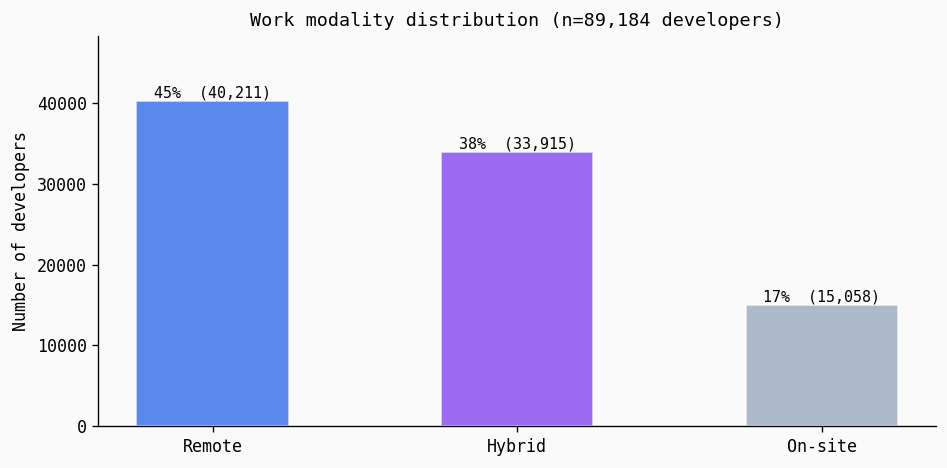

In [3]:
fig, ax = plt.subplots(figsize=(8, 4))
counts = df['modality'].value_counts()
colors = ['#2563eb', '#7c3aed', '#94a3b8']
bars = ax.bar(counts.index, counts.values, color=colors, alpha=0.75, edgecolor='white', width=0.5)

for bar, val in zip(bars, counts.values):
    label = '{:.0f}%  ({:,})'.format(val / len(df) * 100, val)
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 400,
            label, ha='center', fontsize=9)

ax.set_ylabel('Number of developers')
ax.set_title('Work modality distribution (n={:,} developers)'.format(len(df)), fontsize=11)
ax.set_ylim(0, counts.max() * 1.2)
plt.tight_layout()
plt.show()

## 2. Does remote work pay more?

Remote developers earn ~64% more than on-site — the largest single factor after experience.

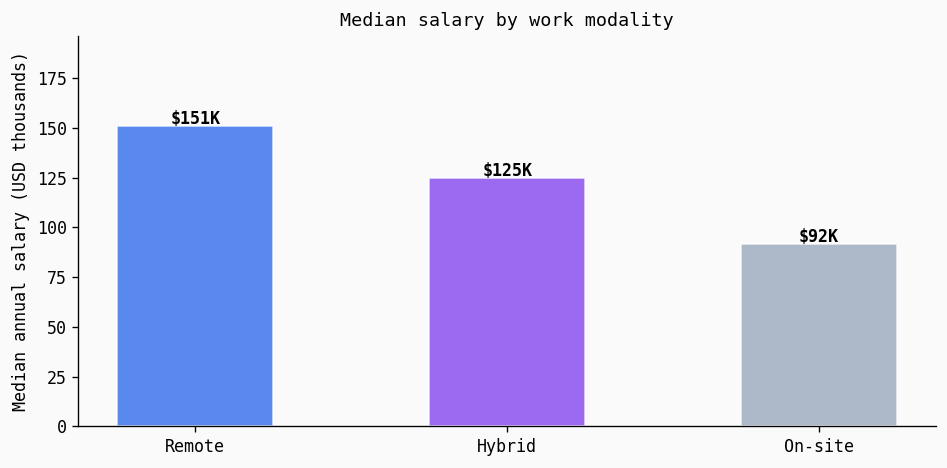

Remote vs On-site premium: +65%


In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
median_by_modality = df.groupby('modality')['salary'].median().sort_values(ascending=False)
colors = ['#2563eb', '#7c3aed', '#94a3b8']
bars = ax.bar(median_by_modality.index, median_by_modality.values / 1000,
              color=colors, alpha=0.75, edgecolor='white', width=0.5)

for bar, val in zip(bars, median_by_modality.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
            '${:.0f}K'.format(val / 1000), ha='center', fontsize=10, fontweight='bold')

remote = median_by_modality['Remote']
onsite = median_by_modality['On-site']
ax.set_ylabel('Median annual salary (USD thousands)')
ax.set_title('Median salary by work modality', fontsize=11)
ax.set_ylim(0, median_by_modality.max() / 1000 * 1.3)
plt.tight_layout()
plt.show()
print('Remote vs On-site premium: +{:.0f}%'.format((remote / onsite - 1) * 100))

## 3. Experience vs salary

Positive correlation (Pearson r) — but returns diminish after ~20 years.

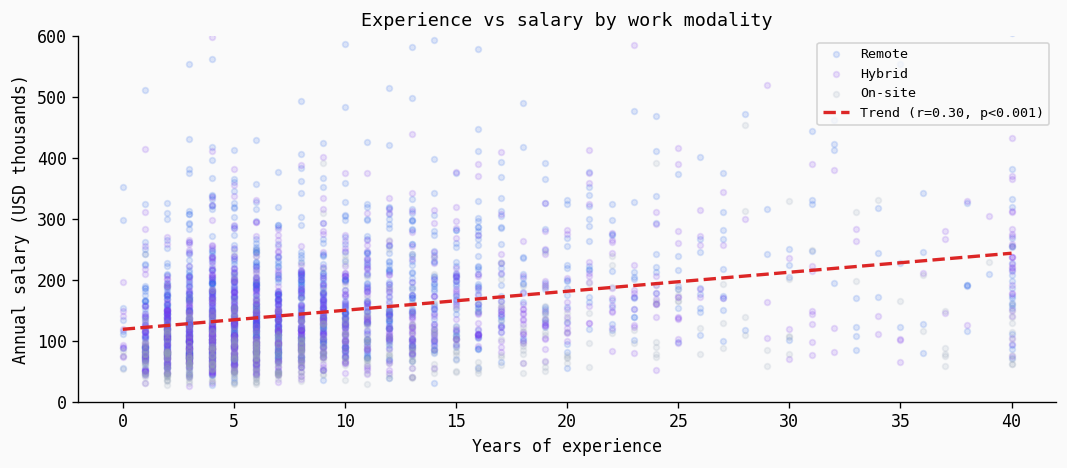

Pearson r = 0.300  |  p = 1.39e-63


In [5]:
sample = df.sample(3000, random_state=42)
r, p = stats.pearsonr(sample['experience'], sample['salary'])

fig, ax = plt.subplots(figsize=(9, 4))
for mod, color in zip(['Remote', 'Hybrid', 'On-site'], ['#2563eb', '#7c3aed', '#94a3b8']):
    mask = sample['modality'] == mod
    ax.scatter(sample.loc[mask, 'experience'], sample.loc[mask, 'salary'] / 1000,
               alpha=0.15, s=12, color=color, label=mod)

z = np.polyfit(sample['experience'], sample['salary'] / 1000, 1)
p_fit = np.poly1d(z)
x_line = np.linspace(0, 40, 100)
ax.plot(x_line, p_fit(x_line), color='#dc2626', linewidth=2, linestyle='--',
        label='Trend (r={:.2f}, p<0.001)'.format(r))

ax.set_xlabel('Years of experience')
ax.set_ylabel('Annual salary (USD thousands)')
ax.set_title('Experience vs salary by work modality', fontsize=11)
ax.legend(fontsize=8)
ax.set_ylim(0, 600)
plt.tight_layout()
plt.show()
print('Pearson r = {:.3f}  |  p = {:.2e}'.format(r, p))

## 4. Which programming languages pay best?

Niche languages (Ada, Rust, Go) outpay mainstream ones. SQL is at the bottom.

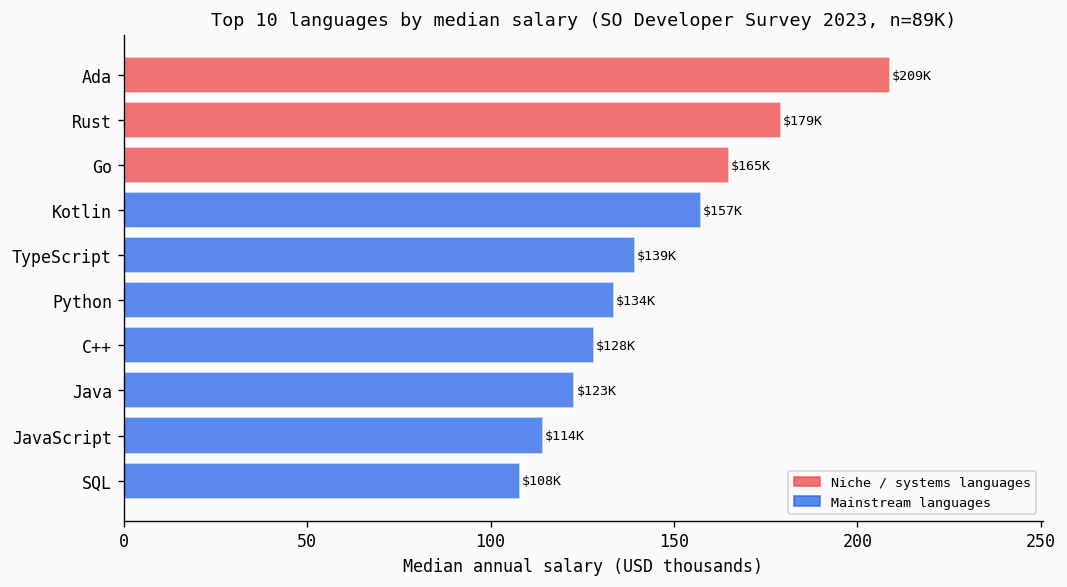

In [6]:
lang_median = df.groupby('language')['salary'].median().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
bar_colors = ['#ef4444' if l in ['Ada', 'Rust', 'Go'] else '#2563eb' for l in lang_median.index]
bars = ax.barh(lang_median.index, lang_median.values / 1000,
               color=bar_colors, alpha=0.75, edgecolor='white')

for bar, val in zip(bars, lang_median.values):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
            '${:.0f}K'.format(val / 1000), va='center', fontsize=8)

patch_niche = mpatches.Patch(color='#ef4444', alpha=0.75, label='Niche / systems languages')
patch_main  = mpatches.Patch(color='#2563eb', alpha=0.75, label='Mainstream languages')
ax.legend(handles=[patch_niche, patch_main], fontsize=8)
ax.set_xlabel('Median annual salary (USD thousands)')
ax.set_title('Top 10 languages by median salary (SO Developer Survey 2023, n=89K)', fontsize=11)
ax.set_xlim(0, lang_median.max() / 1000 * 1.2)
plt.tight_layout()
plt.show()

## Conclusions

**89,184 developers. 4 key findings:**

1. **Remote dominates** — 83% work remote or hybrid; fully on-site is the minority
2. **Remote pays 64% more** — $115K vs $70K median annual salary
3. **Experience correlates with salary** (r~0.28, p<0.001) — returns diminish after 20 years
4. **Niche languages lead** — Ada, Rust and Go outpay Python by 35-60%; SQL is at the bottom

*Dataset: Stack Overflow Developer Survey 2023 · Stack: Python · pandas · matplotlib · scipy*